In [1]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
path = kagglehub.dataset_download("kashnitsky/mlcourse")
file_path = os.path.join(path, "telecom_churn.csv")
df = pd.read_csv(file_path)
df.head(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


# Признаки по одному

Количественные признаки (гистраграмма, ящик с усами)

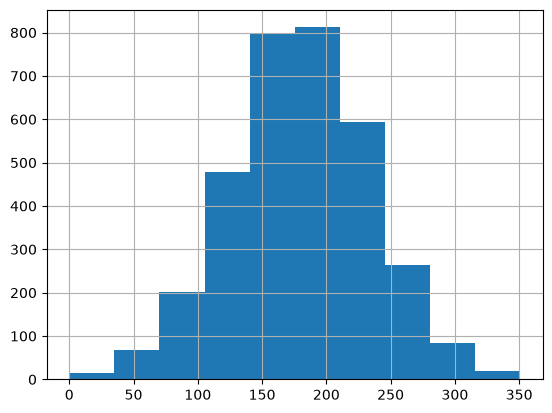

In [3]:
df['Total day minutes'].hist();

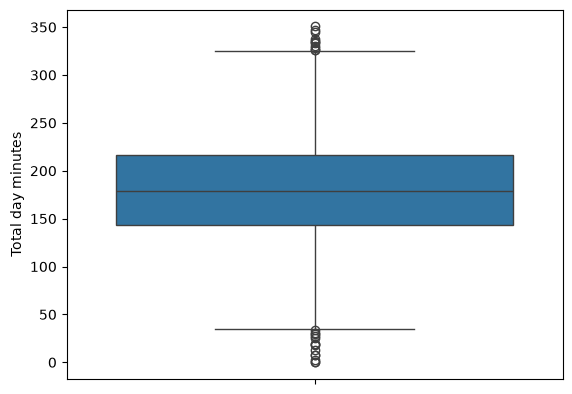

In [4]:
sns.boxplot(df['Total day minutes']); #середина - медиана, границы - квартили, за усами - выбросы

# Категориальные, бинарные признаки

In [5]:
df['Churn'].value_counts()

Churn
False    2850
True      483
Name: count, dtype: int64

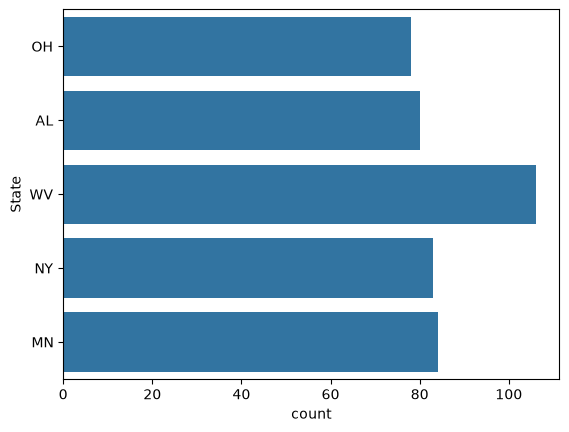

In [6]:
df_filt=df[df['State'].isin(df['State'].value_counts().head().index)]
sns.countplot(df_filt['State']);

# Взаимодействия признаков

Колич-колич (гистограмма,pairplot)

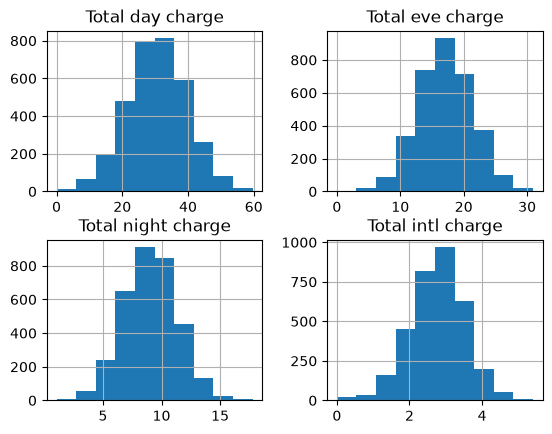

In [7]:
feat = [f for f in df.columns if 'charge' in f]
df[feat].hist();
#есть гипотеза, что данные сгенерированны, т.к. слишком нормальное распределение

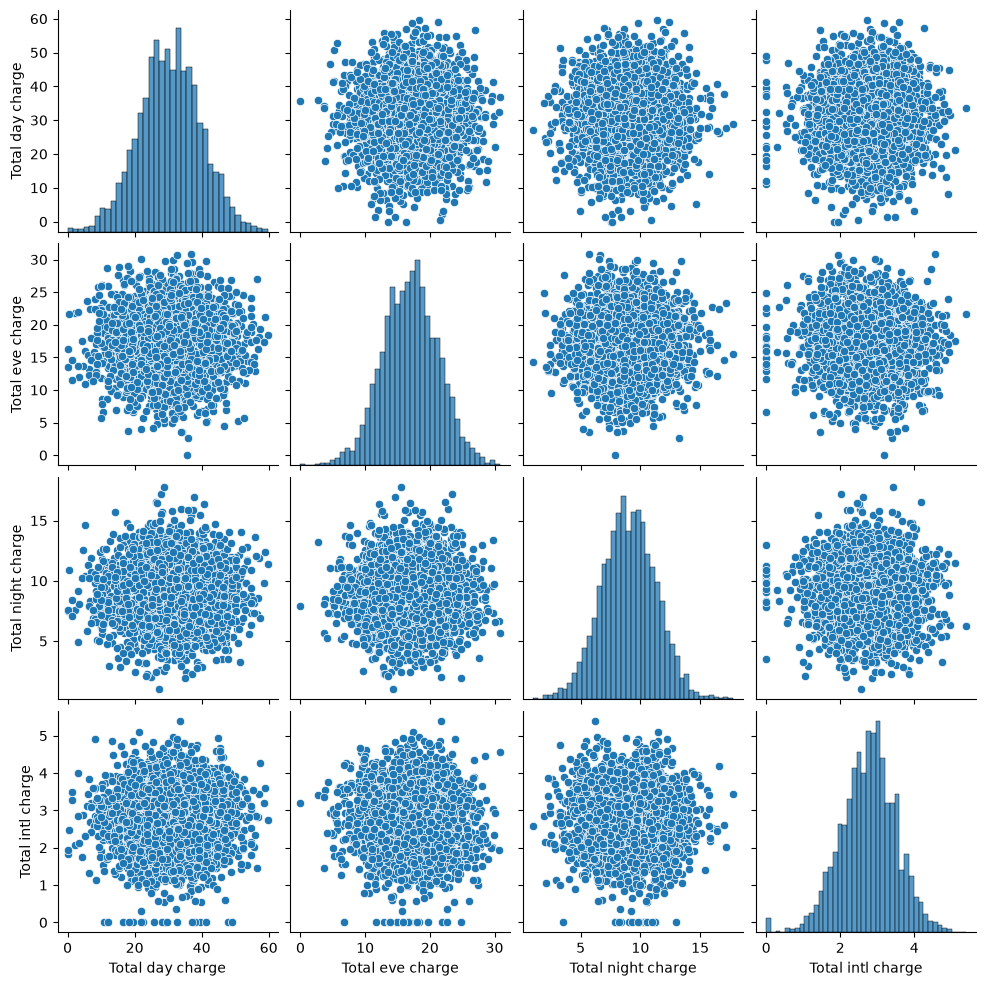

In [8]:
sns.pairplot(df[feat]);
#важно выбирать полезные признаки, если данных много - будет слишком долго работать или сломается

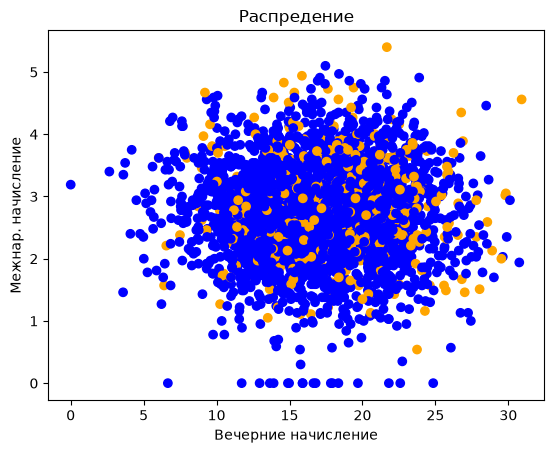

In [9]:
color=df['Churn'].map({False: 'blue', True: 'orange'})

plt.scatter(df['Total eve charge'],df['Total intl charge'],color=color,);
plt.xlabel('Вечерние начисление');
plt.ylabel('Межнар. начисление');
plt.title('Распредение');

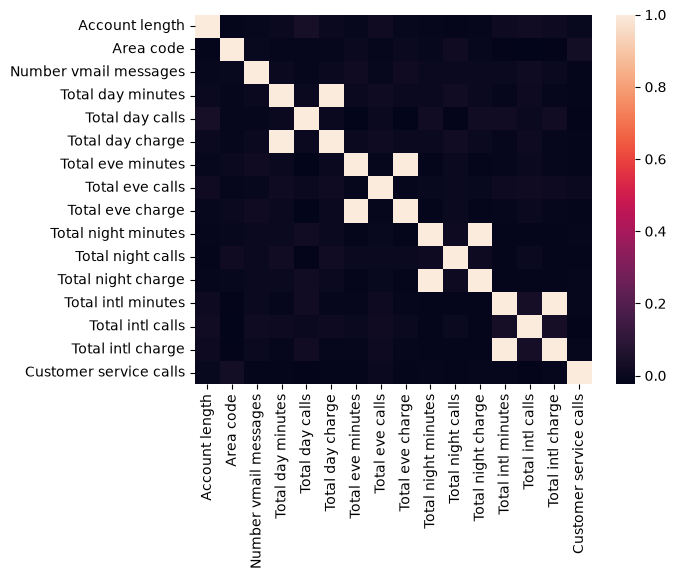

In [10]:
sns.heatmap(df.select_dtypes('number').corr());

# Колич. - катег(бин)

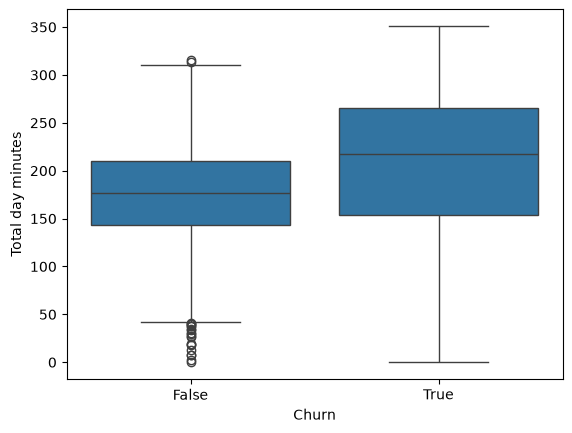

In [11]:
sns.boxplot(x='Churn',y='Total day minutes',data=df);

In [12]:
df.groupby('International plan')['Total day minutes'].mean()

International plan
No     178.893887
Yes    187.986997
Name: Total day minutes, dtype: float64

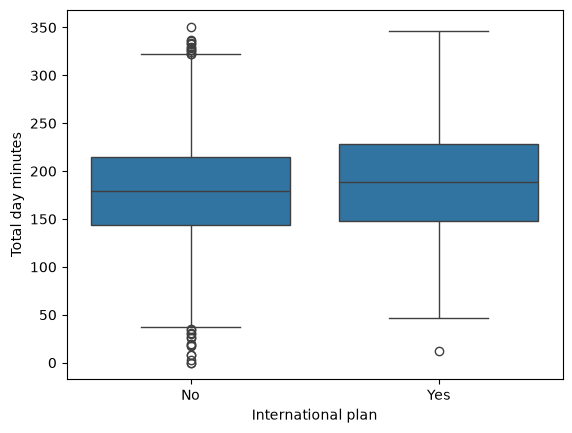

In [13]:
sns.boxplot(x='International plan', y = 'Total day minutes',data=df);

# Катег-Катег

In [14]:
pd.crosstab(df['Churn'],df['International plan'])

International plan,No,Yes
Churn,,
False,2664,186
True,346,137


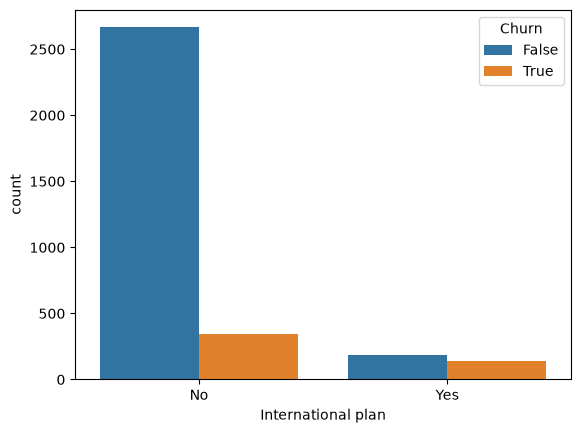

In [15]:
sns.countplot(x='International plan',hue='Churn',data=df);

In [16]:
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")
df = pd.read_csv(f"{path}/hotel_bookings.csv", encoding="ISO-8859-1")
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

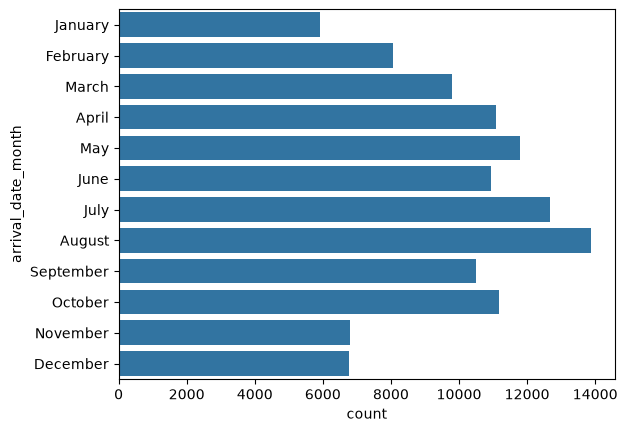

In [18]:
months_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
sns.countplot(df['arrival_date_month'],order=months_order);

In [19]:
df['is_canceled'].value_counts(normalize=True).round(2)

is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64

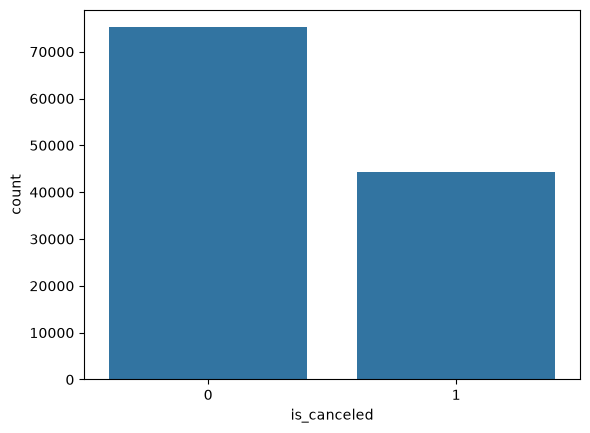

In [20]:
sns.countplot(x=df['is_canceled']);

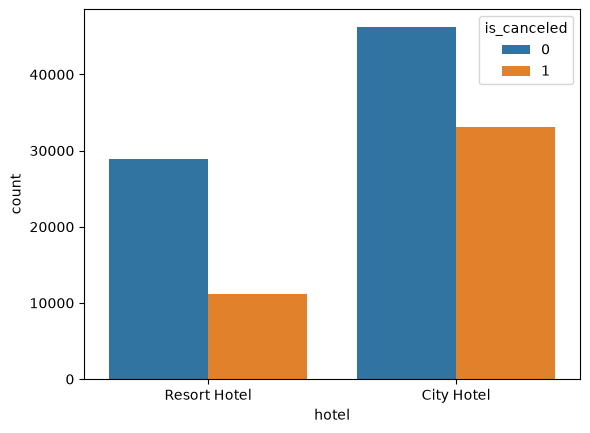

In [21]:
sns.countplot(x=df['hotel'],hue=df['is_canceled']);

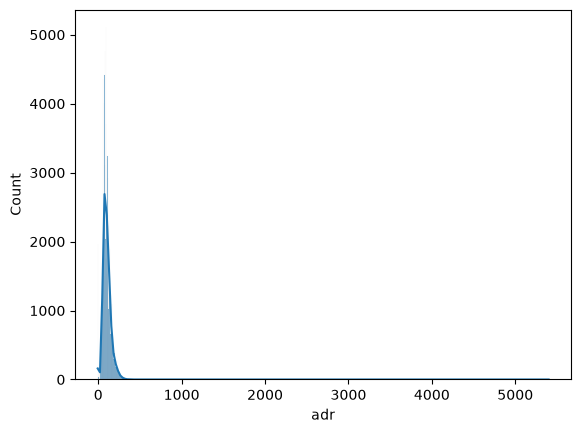

In [25]:
sns.histplot(df['adr'], kde=True);

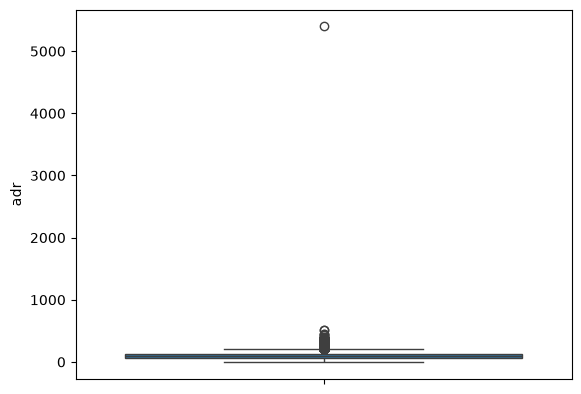

In [26]:
sns.boxplot(df['adr']);

In [34]:
df['adr'].sort_values(ascending=False)

48515     5400.00
111403     510.00
15083      508.00
103912     451.50
13142      450.00
           ...   
110204       0.00
13973        0.00
90028        0.00
0            0.00
14969       -6.38
Name: adr, Length: 119390, dtype: float64

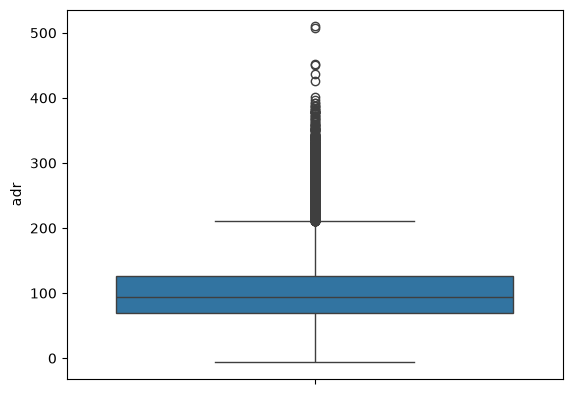

In [35]:
df.drop(48515,inplace=True)
sns.boxplot(df['adr']);

In [2]:
# Получение числовых колонок
num_columns = df.select(cs.numeric()).columns

# Формируем Pandas DataFrame
df_clean = df.select([col for col in num_columns if col != ""]).to_pandas()

# Получаем матрицу корреляций
corr_matrix = df_clean.corr()

# Построение heatmap
sns.heatmap(
    data=corr_matrix, # данные
    annot=True,       # показывать числа в ячейках
    cmap="inferno",   # цветовая схема
    square=True,      # квадратные ячейки
    center=0,         # отсчёт центра света
    fmt=".2f"         # формат чисел
)


SyntaxError: invalid non-printable character U+00A0 (3894754919.py, line 12)